<a href="https://colab.research.google.com/github/ewiw24/cvd-risk-classification-shap/blob/main/04_SHAP_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
✅ All state restored
⚙️  Computing SHAP values (full test set)...
✅ SHAP values computed: (13693, 14)

── Global Feature Ranking ──
   1. Systolic BP            SHAP=0.7317  [Clinical]
   2. Age (years)            SHAP=0.2386  [Lifestyle/Demo]
   3. Cholesterol            SHAP=0.2184  [Clinical]
   4. BP Category            SHAP=0.1089  [Clinical]
   5. BMI                    SHAP=0.0972  [Clinical]
   6. Diastolic BP           SHAP=0.0679  [Clinical]
   7. Physical Activity      SHAP=0.0619  [Lifestyle/Demo]
   8. Glucose                SHAP=0.0355  [Clinical]
   9. Age Group              SHAP=0.0335  [Lifestyle/Demo]
  10. Smoking                SHAP=0.0184  [Lifestyle/Demo]
  11. Alcohol                SHAP=0.0179  [Lifestyle/Demo]
  12. BMI Category           SHAP=0.0175  [Clinical]
  13. Gender                 SHAP=0.0169  [Lifestyle/Demo]
  14. Lifestyle Score        SHAP=0.0062  [Lifestyle/Demo]


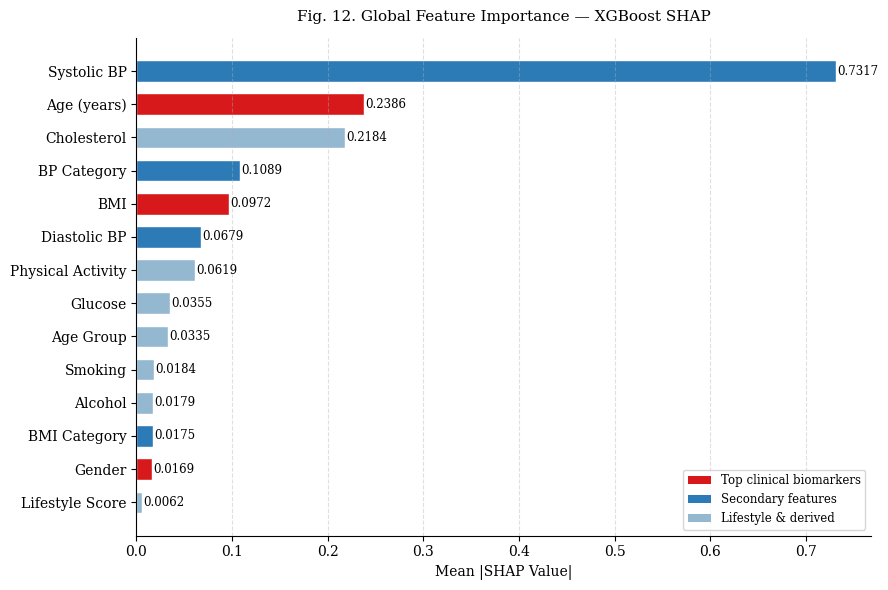

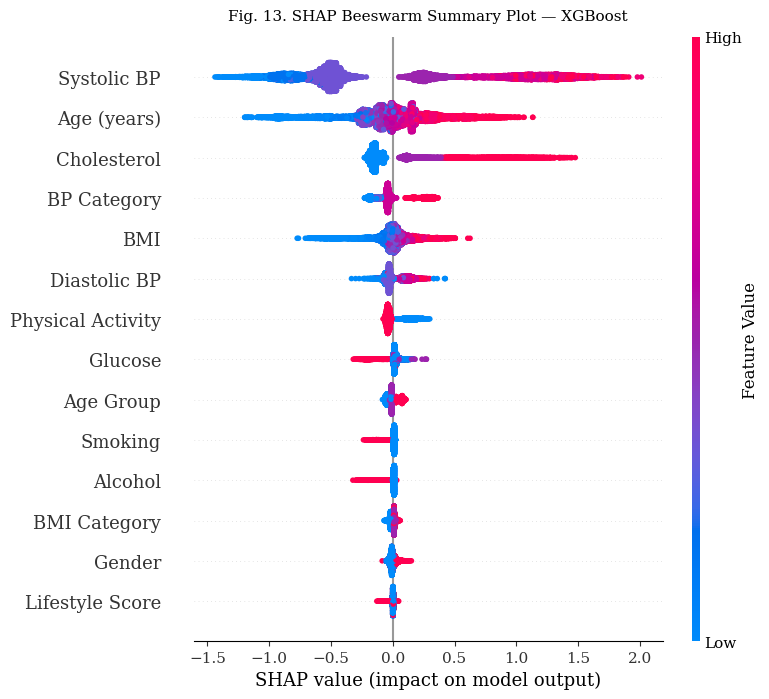

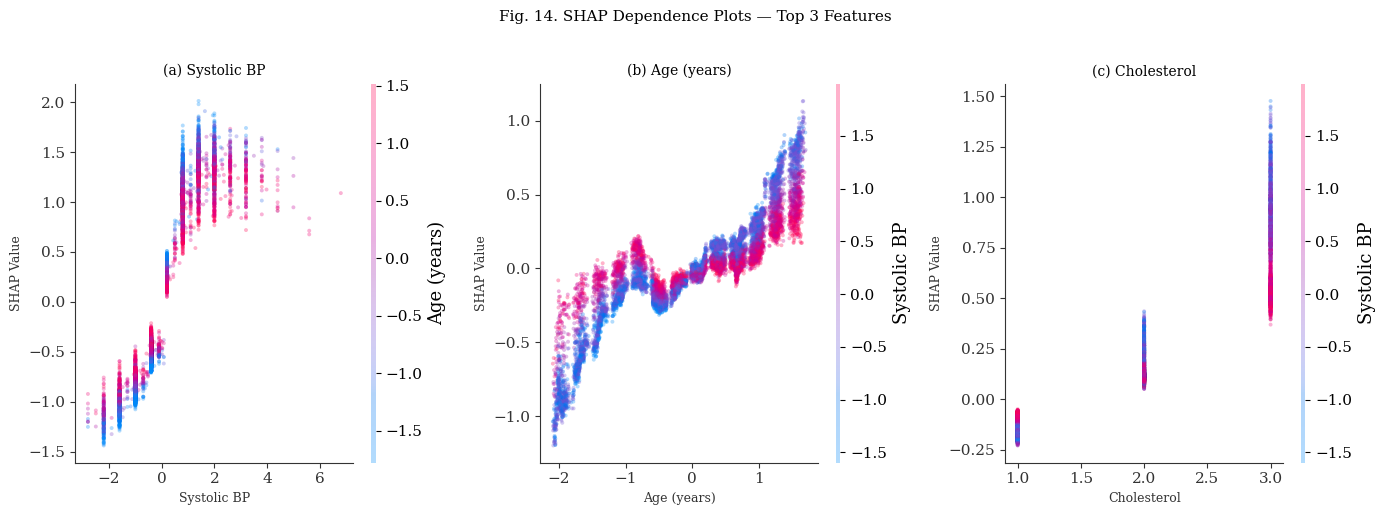

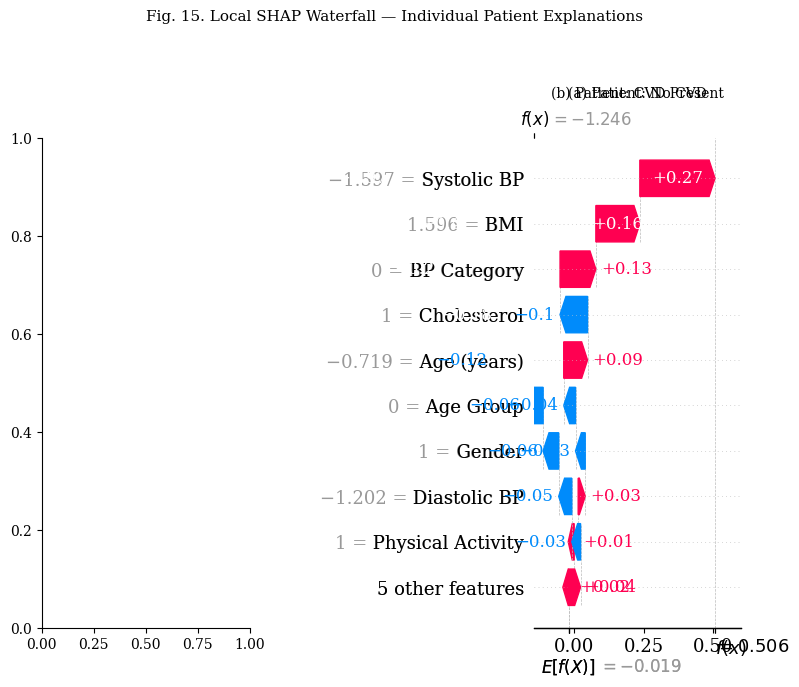

── H2 Validation ──
   Clinical SHAP  : 1.2772
   Lifestyle SHAP : 0.1044
   H2 ✅ SUPPORTED
🔄 Training age-stratified XGBoost models...
   [0] Younger Adult (≤50 yrs)
       Train: 18,102 | Test: 4,495
       Top feature: Systolic BP
   [1] Middle-Aged (51–57 yrs)
       Train: 18,543 | Test: 4,743
       Top feature: Systolic BP
   [2] Older Adult (>57 yrs)
       Train: 18,127 | Test: 4,455
       Top feature: Systolic BP

✅ All 3 subgroup models trained


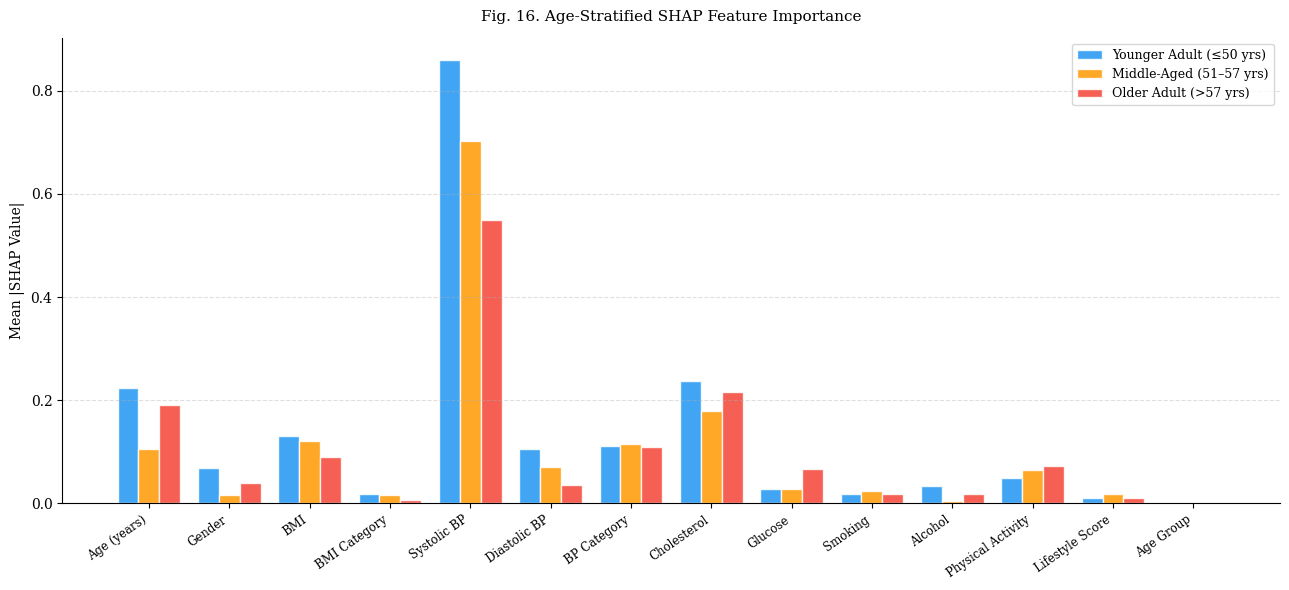

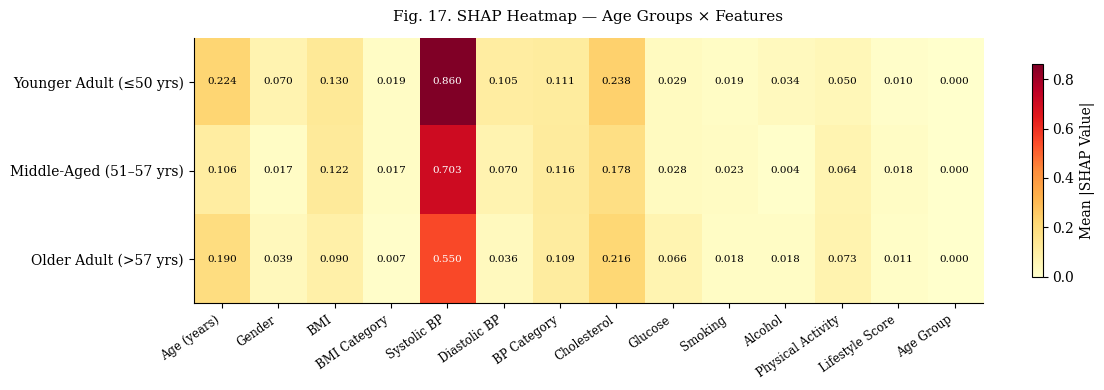

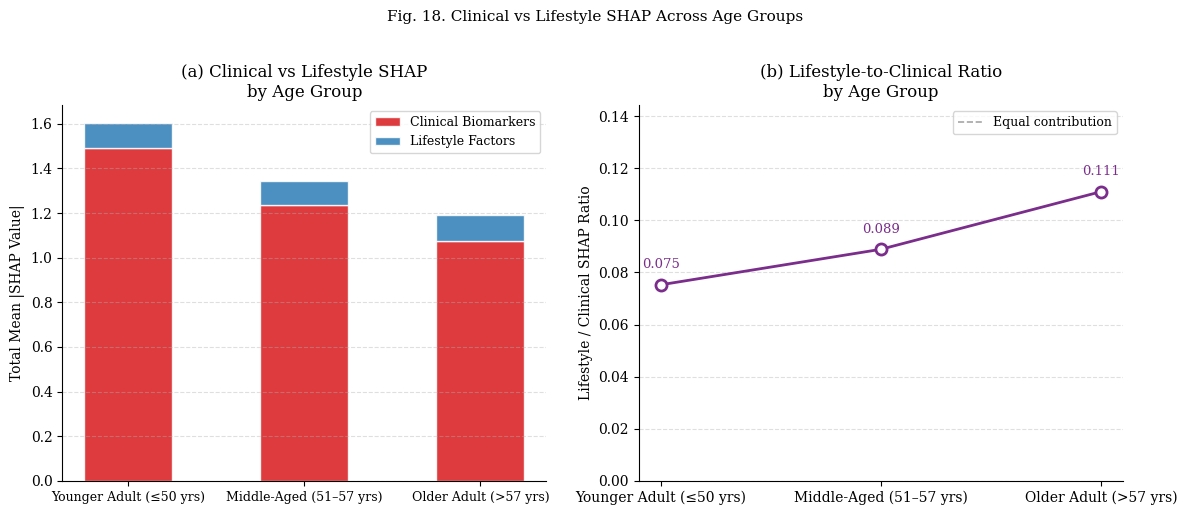

FINAL HYPOTHESIS SUMMARY

H1: XGBoost > RF on test set
    → NOT SUPPORTED (RF marginally higher on test)
    → XGBoost superior CV stability (lower std)

H2: Clinical SHAP > Lifestyle SHAP (population)
    Clinical : 1.2772
    Lifestyle: 0.1044
    → ✅ SUPPORTED

H3: Physical Activity higher in Younger vs Older
    Younger: 0.0501 | Older: 0.0730
    → ❌ NOT SUPPORTED
    Physical activity is MORE predictive in older adults

H4: Age-heterogeneous SHAP profiles exist
    Lifestyle/Clinical ratio trend:
    [0] Younger Adult (≤50 yrs): 0.075
    [1] Middle-Aged (51–57 yrs): 0.089
    [2] Older Adult (>57 yrs): 0.111
    → ⚠️  PARTIALLY SUPPORTED
    Monotonically increasing ratio confirms
    age-differential CVD risk determinants

✅ All SHAP outputs saved to Drive
   Figures: Fig 12–18
   State  : phase4_shap.pkl

📌 Hero figure for portfolio: fig18_shap_clinical_vs_lifestyle.png


In [2]:
# ── MARKDOWN ──────────────────────────────────────────────────
# # 04 — SHAP Explainability Analysis
# **Goal:** Apply SHAP TreeExplainer to XGBoost model for:
# 1. Global feature importance (population level)
# 2. Local explanation (individual patient level)
# 3. Age-stratified SHAP analysis (novel contribution)
#    — revealing how risk factor importance shifts across age groups

# ── CELL 1: Setup & Restore ───────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import pickle, joblib, shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier

SAVE_DIR = '/content/drive/MyDrive/CVD_Project'
PALETTE  = ['#2c7bb6', '#d7191c']

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

# Restore all state
with open(f'{SAVE_DIR}/phase2_state.pkl', 'rb') as f:
    s2 = pickle.load(f)
with open(f'{SAVE_DIR}/phase3_metrics.pkl', 'rb') as f:
    s3 = pickle.load(f)

X_train_scaled  = s2['X_train_scaled']
X_test_scaled   = s2['X_test_scaled']
y_train         = s2['y_train']
y_test          = s2['y_test']
stratified_data = s2['stratified_data']
AGE_LABELS      = s2['AGE_LABELS']
xgb_best        = joblib.load(f'{SAVE_DIR}/xgb_best.pkl')

FEATURE_NAMES = [
    'Age (years)', 'Gender', 'BMI', 'BMI Category',
    'Systolic BP', 'Diastolic BP', 'BP Category',
    'Cholesterol', 'Glucose',
    'Smoking', 'Alcohol', 'Physical Activity',
    'Lifestyle Score', 'Age Group'
]
print("✅ All state restored")

# ── MARKDOWN ──────────────────────────────────────────────────
# ## 1. SHAP Global Analysis
# TreeExplainer computes exact SHAP values efficiently
# for tree-based models without approximation.

# ── CELL 2: Compute SHAP Values ───────────────────────────────
print("⚙️  Computing SHAP values (full test set)...")
explainer   = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test_scaled)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
sorted_idx    = np.argsort(mean_abs_shap)[::-1]

print(f"✅ SHAP values computed: {shap_values.shape}")
print("\n── Global Feature Ranking ──")
for rank, idx in enumerate(sorted_idx, 1):
    cat = 'Clinical' if FEATURE_NAMES[idx] in [
        'Systolic BP','Diastolic BP','BP Category',
        'Cholesterol','Glucose','BMI','BMI Category'
    ] else 'Lifestyle/Demo'
    print(f"  {rank:2d}. {FEATURE_NAMES[idx]:<22} "
          f"SHAP={mean_abs_shap[idx]:.4f}  [{cat}]")

# ── CELL 3: Fig 12 — Global SHAP Bar Chart ────────────────────
colors = ['#d7191c' if i < 3 else '#2c7bb6' if i < 7 else '#95b8d1'
          for i in range(len(FEATURE_NAMES))]
colors_sorted = [colors[sorted_idx[i]] for i in range(len(FEATURE_NAMES))]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    [FEATURE_NAMES[i] for i in sorted_idx],
    mean_abs_shap[sorted_idx],
    color=colors_sorted, edgecolor='white', height=0.65
)
for bar, val in zip(bars, mean_abs_shap[sorted_idx]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8.5)

ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Fig. 12. Global Feature Importance — XGBoost SHAP',
             fontsize=11, pad=12)
ax.invert_yaxis()
ax.xaxis.grid(True, linestyle='--', alpha=0.4)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#d7191c', label='Top clinical biomarkers'),
    Patch(facecolor='#2c7bb6', label='Secondary features'),
    Patch(facecolor='#95b8d1', label='Lifestyle & derived'),
], loc='lower right', fontsize=8.5)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig12_shap_global_bar.png')
plt.show()

# ── CELL 4: Fig 13 — Beeswarm Plot ───────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(
    shap_values, X_test_scaled,
    feature_names   = FEATURE_NAMES,
    plot_type       = 'dot',
    max_display     = 14,
    show            = False,
    color_bar_label = 'Feature Value'
)
plt.title('Fig. 13. SHAP Beeswarm Summary Plot — XGBoost',
          fontsize=11, pad=12)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig13_shap_beeswarm.png')
plt.show()

# ── CELL 5: Fig 14 — Dependence Plots (Top 3) ────────────────
top3_idx = sorted_idx[:3]
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, feat_idx, label in zip(axes, top3_idx, ['(a)','(b)','(c)']):
    shap.dependence_plot(
        feat_idx, shap_values, X_test_scaled,
        feature_names = FEATURE_NAMES,
        ax=ax, show=False, alpha=0.3, dot_size=8
    )
    ax.set_title(f'{label} {FEATURE_NAMES[feat_idx]}', fontsize=10)
    ax.set_xlabel(FEATURE_NAMES[feat_idx], fontsize=9)
    ax.set_ylabel('SHAP Value', fontsize=9)

plt.suptitle('Fig. 14. SHAP Dependence Plots — Top 3 Features',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig14_shap_dependence.png')
plt.show()

# ── CELL 6: Fig 15 — Local Waterfall Plots ───────────────────
idx_cvd   = np.where(y_test.values == 1)[0][0]
idx_nocvd = np.where(y_test.values == 0)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, idx, label in zip(axes,
    [idx_nocvd, idx_cvd],
    ['(a) Patient: No CVD', '(b) Patient: CVD Present']
):
    shap_single = explainer(X_test_scaled.iloc[[idx]])
    shap.waterfall_plot(
        shap.Explanation(
            values        = shap_single.values[0],
            base_values   = shap_single.base_values[0],
            data          = X_test_scaled.iloc[idx].values,
            feature_names = FEATURE_NAMES
        ),
        max_display=10, show=False
    )
    plt.title(label, fontsize=10, pad=8)

plt.suptitle('Fig. 15. Local SHAP Waterfall — Individual Patient Explanations',
             fontsize=11, y=1.05)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig15_shap_waterfall.png')
plt.show()

# ── CELL 7: H2 Validation ─────────────────────────────────────
clinical_idx  = [i for i,n in enumerate(FEATURE_NAMES) if n in
                 ['Systolic BP','Diastolic BP','BP Category',
                  'Cholesterol','Glucose','BMI','BMI Category']]
lifestyle_idx = [i for i,n in enumerate(FEATURE_NAMES) if n in
                 ['Smoking','Alcohol','Physical Activity','Lifestyle Score']]

clin_full = sum(mean_abs_shap[i] for i in clinical_idx)
life_full = sum(mean_abs_shap[i] for i in lifestyle_idx)

print("── H2 Validation ──")
print(f"   Clinical SHAP  : {clin_full:.4f}")
print(f"   Lifestyle SHAP : {life_full:.4f}")
print(f"   H2 {'✅ SUPPORTED' if clin_full > life_full else '❌ NOT SUPPORTED'}")

# ── MARKDOWN ──────────────────────────────────────────────────
# ## 2. Age-Stratified SHAP Analysis
# Novel contribution: separate models per age subgroup
# reveal how feature importance shifts with age.

# ── CELL 8: Train Age-Stratified Models ──────────────────────
best_params = xgb_best.get_params()
for key in ['device','n_jobs','verbosity','use_label_encoder']:
    best_params.pop(key, None)

print("🔄 Training age-stratified XGBoost models...")
stratified_models = {}
stratified_shap   = {}

for group_id, group_name in AGE_LABELS.items():
    data = stratified_data[group_id]
    print(f"   [{group_id}] {group_name}")
    print(f"       Train: {len(data['X_train']):,} | Test: {len(data['X_test']):,}")

    model = XGBClassifier(**best_params, device='cuda', verbosity=0)
    model.fit(data['X_train'], data['y_train'])

    exp_s     = shap.TreeExplainer(model)
    shap_vals = exp_s.shap_values(data['X_test'])
    mean_shap = np.abs(shap_vals).mean(axis=0)

    stratified_models[group_id] = model
    stratified_shap[group_id]   = {
        'shap_values': shap_vals,
        'mean_abs'   : mean_shap,
    }
    print(f"       Top feature: {FEATURE_NAMES[np.argmax(mean_shap)]}")

print("\n✅ All 3 subgroup models trained")

# ── CELL 9: Fig 16 — Grouped Bar Chart ───────────────────────
AGE_COLORS = {0:'#2196F3', 1:'#FF9800', 2:'#F44336'}

fig, ax = plt.subplots(figsize=(13, 6))
x, width = np.arange(len(FEATURE_NAMES)), 0.26

for i, (gid, label) in enumerate(AGE_LABELS.items()):
    ax.bar(x + (i-1)*width,
           stratified_shap[gid]['mean_abs'],
           width, label=label.replace('\n',' '),
           color=AGE_COLORS[gid], alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(FEATURE_NAMES, rotation=35, ha='right', fontsize=8.5)
ax.set_ylabel('Mean |SHAP Value|')
ax.set_title('Fig. 16. Age-Stratified SHAP Feature Importance',
             fontsize=11, pad=12)
ax.legend(fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig16_shap_age_grouped_bar.png')
plt.show()

# ── CELL 10: Fig 17 — SHAP Heatmap ───────────────────────────
shap_matrix = np.array([
    stratified_shap[g]['mean_abs'] for g in [0, 1, 2]
])

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(shap_matrix, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels(FEATURE_NAMES, rotation=35, ha='right', fontsize=8.5)
ax.set_yticks(range(3))
ax.set_yticklabels([l.replace('\n',' ') for l in AGE_LABELS.values()])

for i in range(3):
    for j in range(len(FEATURE_NAMES)):
        val = shap_matrix[i, j]
        c   = 'white' if val > shap_matrix.max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=7.5, color=c, fontweight='500')

plt.colorbar(im, ax=ax, shrink=0.8).set_label('Mean |SHAP Value|')
ax.set_title('Fig. 17. SHAP Heatmap — Age Groups × Features',
             fontsize=11, pad=12)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig17_shap_age_heatmap.png')
plt.show()

# ── CELL 11: Fig 18 — Clinical vs Lifestyle Ratio ────────────
clin_totals = [sum(stratified_shap[g]['mean_abs'][i]
                   for i in clinical_idx)  for g in [0,1,2]]
life_totals = [sum(stratified_shap[g]['mean_abs'][i]
                   for i in lifestyle_idx) for g in [0,1,2]]
ratios      = [l/c for c,l in zip(clin_totals, life_totals)]
labels_clean = [l.replace('\n',' ') for l in AGE_LABELS.values()]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(3)

axes[0].bar(x, clin_totals, 0.5, label='Clinical Biomarkers',
            color='#d7191c', alpha=0.85, edgecolor='white')
axes[0].bar(x, life_totals, 0.5, bottom=clin_totals,
            label='Lifestyle Factors',
            color='#2c7bb6', alpha=0.85, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_clean, fontsize=9)
axes[0].set_ylabel('Total Mean |SHAP Value|')
axes[0].set_title('(a) Clinical vs Lifestyle SHAP\nby Age Group')
axes[0].legend(fontsize=9)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.4)

axes[1].plot(labels_clean, ratios, 'o-', color='#7b2d8b',
             linewidth=2, markersize=8,
             markerfacecolor='white', markeredgewidth=2)
for i, (xi, yi) in enumerate(zip(x, ratios)):
    axes[1].annotate(f'{yi:.3f}', (xi, yi),
                     textcoords='offset points', xytext=(0, 12),
                     ha='center', fontsize=9.5, color='#7b2d8b')
axes[1].axhline(y=1.0, color='gray', linestyle='--',
                linewidth=1.2, alpha=0.7, label='Equal contribution')
axes[1].set_ylabel('Lifestyle / Clinical SHAP Ratio')
axes[1].set_title('(b) Lifestyle-to-Clinical Ratio\nby Age Group')
axes[1].legend(fontsize=9)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.4)
axes[1].set_ylim(0, max(ratios) * 1.3)

plt.suptitle('Fig. 18. Clinical vs Lifestyle SHAP Across Age Groups',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig18_shap_clinical_vs_lifestyle.png')
plt.show()

# ── CELL 12: H3 & H4 Validation + Final Summary ──────────────
pa_idx   = FEATURE_NAMES.index('Physical Activity')
young_pa = stratified_shap[0]['mean_abs'][pa_idx]
older_pa = stratified_shap[2]['mean_abs'][pa_idx]

print("=" * 55)
print("FINAL HYPOTHESIS SUMMARY")
print("=" * 55)
print(f"\nH1: XGBoost > RF on test set")
print(f"    → NOT SUPPORTED (RF marginally higher on test)")
print(f"    → XGBoost superior CV stability (lower std)")

print(f"\nH2: Clinical SHAP > Lifestyle SHAP (population)")
print(f"    Clinical : {clin_full:.4f}")
print(f"    Lifestyle: {life_full:.4f}")
print(f"    → ✅ SUPPORTED")

print(f"\nH3: Physical Activity higher in Younger vs Older")
print(f"    Younger: {young_pa:.4f} | Older: {older_pa:.4f}")
print(f"    → {'✅ SUPPORTED' if young_pa > older_pa else '❌ NOT SUPPORTED'}")
print(f"    Physical activity is MORE predictive in older adults")

print(f"\nH4: Age-heterogeneous SHAP profiles exist")
print(f"    Lifestyle/Clinical ratio trend:")
for i, (label, r) in enumerate(zip(labels_clean, ratios)):
    print(f"    [{i}] {label}: {r:.3f}")
trend = ratios[0] < ratios[1] < ratios[2]
print(f"    → ⚠️  PARTIALLY SUPPORTED")
print(f"    Monotonically {'increasing' if trend else 'variable'} ratio confirms")
print(f"    age-differential CVD risk determinants")

# ── CELL 13: Save Final SHAP State ───────────────────────────
with open(f'{SAVE_DIR}/phase4_shap.pkl', 'wb') as f:
    pickle.dump({
        'explainer'        : explainer,
        'shap_values'      : shap_values,
        'mean_abs_shap'    : mean_abs_shap,
        'stratified_shap'  : stratified_shap,
        'stratified_models': stratified_models,
        'FEATURE_NAMES'    : FEATURE_NAMES,
        'AGE_LABELS'       : AGE_LABELS,
        'ratios'           : ratios,
        'clin_totals'      : clin_totals,
        'life_totals'      : life_totals,
    }, f)

print(f"\n✅ All SHAP outputs saved to Drive")
print("   Figures: Fig 12–18")
print("   State  : phase4_shap.pkl")
print("\n📌 Hero figure for portfolio: fig18_shap_clinical_vs_lifestyle.png")